In [3]:
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ----------------------

ERROR: Could not install packages due to an OSError: [WinError 32] Процесс не может получить доступ к файлу, так как этот файл занят другим процессом: 'C:\\Users\\Пк\\AppData\\Roaming\\Python\\Python311\\site-packages\\sklearn\\cluster\\_hdbscan\\__init__.py'
Check the permissions.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.2-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.1 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.1 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.1 MB 1.2 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.1 MB 1.2 MB/s eta 0:00:05
   ------------ --------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# 🍷 WINE QUALITY PREDICTION - COMPLETE EDA AND MODEL

# 1. ЗАГРУЗКА ДАННЫХ И БИБЛИОТЕК

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')


print("ЗАГРУЗКА ДАННЫХ")


red_wine = pd.read_csv('../data/winequality-red.csv', sep=';')
white_wine = pd.read_csv('../data/winequality-white.csv', sep=';')

print(f"\n Красное вино: {red_wine.shape[0]} строк, {red_wine.shape[1]} признаков")
print(f"Белое вино: {white_wine.shape[0]} строк, {white_wine.shape[1]} признаков")

# Добавление типа вина
red_wine['wine_type'] = 'red'
white_wine['wine_type'] = 'white'

# Объединение датасетов
df = pd.concat([red_wine, white_wine], ignore_index=True)
print(f"\n Объединённый датасет: {df.shape[0]} строк, {df.shape[1]} признаков")



ЗАГРУЗКА ДАННЫХ

 Красное вино: 1599 строк, 12 признаков
Белое вино: 4898 строк, 12 признаков

 Объединённый датасет: 6497 строк, 13 признаков


In [17]:
# 2.1 Просмотр первых строк
print("\n Первые 5 строк данных:")
print(df.head())



 Первые 5 строк данных:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality wine_type  
0      9.4        5       red

In [18]:
# 2.2 Информация о датасете
print("\n Информация о датасете:")
print(df.info())



 Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB
None


In [19]:
# 2.3 Статистическое описание
print("\n Статистическое описание:")
print(df.describe())



 Статистическое описание:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000   

In [21]:
# 2.4 Проверка на пропуски
print("\n Проверка на пропуски:")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_percent})
print(missing_df[missing_df['Пропуски'] > 0] if missing.sum() > 0 else " Пропусков нет!")



 Проверка на пропуски:
 Пропусков нет!


In [22]:
# 2.5 Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"\n Дубликаты: {duplicates} ({(duplicates/len(df)*100):.2f}%)")



 Дубликаты: 1177 (18.12%)


In [23]:
# 2.6 Распределение целевой переменной (quality)
print("\n Распределение качества вина:")
print(df['quality'].value_counts().sort_index())



 Распределение качества вина:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [24]:
# 3. ВИЗУАЛИЗАЦИЯ
print(" ВИЗУАЛИЗАЦИЯ")

# Создаём фигуру для всех графиков
fig = plt.figure(figsize=(20, 15))



 ВИЗУАЛИЗАЦИЯ


<Figure size 2000x1500 with 0 Axes>

Text(0, 0.5, 'Count')

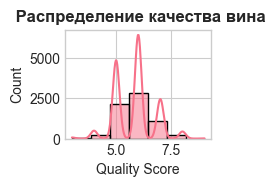

In [25]:
# 3.1 Распределение quality (гистограмма)
plt.subplot(3, 3, 1)
sns.histplot(data=df, x='quality', bins=df['quality'].nunique(), kde=True)
plt.title(' Распределение качества вина', fontsize=12, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')


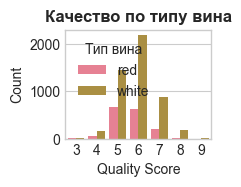

In [26]:
# 3.2 Распределение quality по типу вина
plt.subplot(3, 3, 2)
sns.countplot(data=df, x='quality', hue='wine_type')
plt.title('Качество по типу вина', fontsize=12, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.legend(title='Тип вина')


Text(0, 0.5, 'Quality Score')

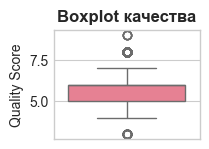

In [27]:
# 3.3 Boxplot распределения quality
plt.subplot(3, 3, 3)
sns.boxplot(data=df, y='quality')
plt.title('Boxplot качества', fontsize=12, fontweight='bold')
plt.ylabel('Quality Score')


Text(0.5, 1.0, 'Корреляционная матрица')

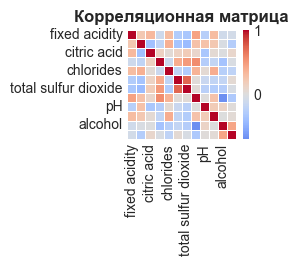

In [28]:
# 3.4 Корреляционная матрица (heatmap)
plt.subplot(3, 3, 4)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=12, fontweight='bold')


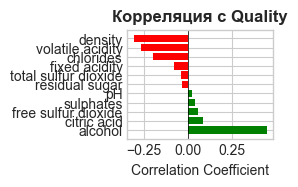

In [29]:
# 3.5 Корреляция с target (quality)
plt.subplot(3, 3, 5)
corr_with_target = corr_matrix['quality'].drop('quality').sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.title('Корреляция с Quality', fontsize=12, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)


Text(0, 0.5, 'Quality Score')

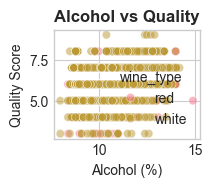

In [30]:

# 3.6 Scatter plot: alcohol vs quality
plt.subplot(3, 3, 6)
sns.scatterplot(data=df, x='alcohol', y='quality', alpha=0.5, hue='wine_type')
plt.title('Alcohol vs Quality', fontsize=12, fontweight='bold')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality Score')


Text(0, 0.5, 'Quality Score')

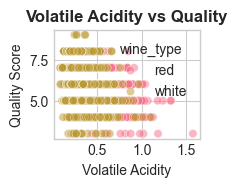

In [31]:

# 3.7 Scatter plot: volatile acidity vs quality
plt.subplot(3, 3, 7)
sns.scatterplot(data=df, x='volatile acidity', y='quality', alpha=0.5, hue='wine_type')
plt.title('Volatile Acidity vs Quality', fontsize=12, fontweight='bold')
plt.xlabel('Volatile Acidity')
plt.ylabel('Quality Score')


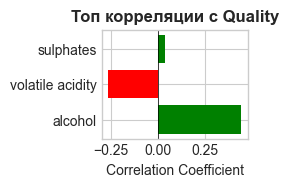

In [34]:
# 3.8 Pairplot для ключевых признаков
plt.subplot(3, 3, 8)
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'quality']
pair_corr = df[key_features].corr()['quality'].drop('quality')
plt.barh(pair_corr.index, pair_corr.values, color=['green' if x > 0 else 'red' for x in pair_corr.values])
plt.title('Топ корреляции с Quality', fontsize=12, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)



✅ Графики сохранены в ../notebook/eda_visualizations.png


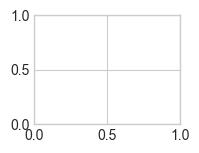

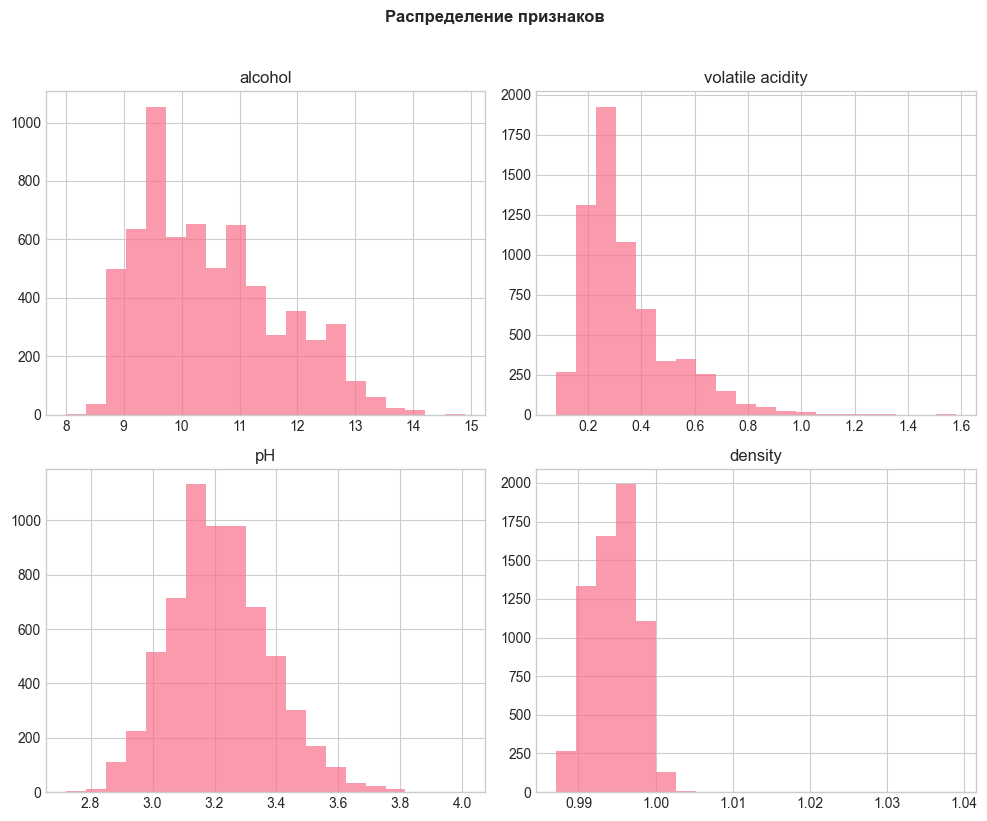

In [35]:
# 3.9 Распределение основных признаков
plt.subplot(3, 3, 9)
df[['alcohol', 'volatile acidity', 'pH', 'density']].hist(bins=20, figsize=(10, 8), alpha=0.7)
plt.suptitle('Распределение признаков', fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../notebook/eda_visualizations.png', dpi=300, bbox_inches='tight')
print("\n✅ Графики сохранены в ../notebook/eda_visualizations.png")
plt.show()


In [36]:

# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ")

# Удаляем дубликаты
df_clean = df.drop_duplicates()
print(f"\n После удаления дубликатов: {df_clean.shape[0]} строк")

# Бинарная классификация: quality > 6 = good (1), else bad (0)
df_clean['quality_binary'] = (df_clean['quality'] > 6).astype(int)

print(f"\n Распределение бинарного качества:")
print(df_clean['quality_binary'].value_counts())
print(f"\n Good wine (1): {(df_clean['quality_binary'] == 1).sum()} ({(df_clean['quality_binary'] == 1).mean()*100:.1f}%)")
print(f" Bad wine (0): {(df_clean['quality_binary'] == 0).sum()} ({(df_clean['quality_binary'] == 0).mean()*100:.1f}%)")

# Признаки и целевая переменная
feature_columns = [col for col in df_clean.columns if col not in ['quality', 'quality_binary', 'wine_type']]
X = df_clean[feature_columns]
y = df_clean['quality_binary']

print(f"\n Признаки ({len(feature_columns)}): {feature_columns}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

print(f"\n Train set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Признаки масштабированы (StandardScaler)")



ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ

 После удаления дубликатов: 5320 строк

 Распределение бинарного качества:
quality_binary
0    4311
1    1009
Name: count, dtype: int64

 Good wine (1): 1009 (19.0%)
 Bad wine (0): 4311 (81.0%)

 Признаки (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

 Train set: 4256 samples
 Test set: 1064 samples

 Признаки масштабированы (StandardScaler)


In [37]:
# 5. ОБУЧЕНИЕ МОДЕЛИ
print(" ОБУЧЕНИЕ МОДЕЛИ")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)

print("\n Параметры модели:")
print(f"  - n_estimators: 100")
print(f"  - max_depth: 10")
print(f"  - random_state: 42")
print(f"  - class_weight: balanced")

# Обучение
print("\n Обучение модели...")
model.fit(X_train_scaled, y_train)
print(" Модель обучена!")



 ОБУЧЕНИЕ МОДЕЛИ

 Параметры модели:
  - n_estimators: 100
  - max_depth: 10
  - random_state: 42
  - class_weight: balanced

 Обучение модели...
 Модель обучена!



 ОЦЕНКА МОДЕЛИ

 Accuracy: 0.8195 (81.95%)

 Classification Report:
              precision    recall  f1-score   support

     Bad (0)       0.91      0.86      0.89       862
    Good (1)       0.52      0.65      0.58       202

    accuracy                           0.82      1064
   macro avg       0.72      0.76      0.73      1064
weighted avg       0.84      0.82      0.83      1064


 Confusion Matrix:
[[740 122]
 [ 70 132]]

 ROC-AUC: 0.8631


FileNotFoundError: [Errno 2] No such file or directory: '../notebooks/model_evaluation.png'

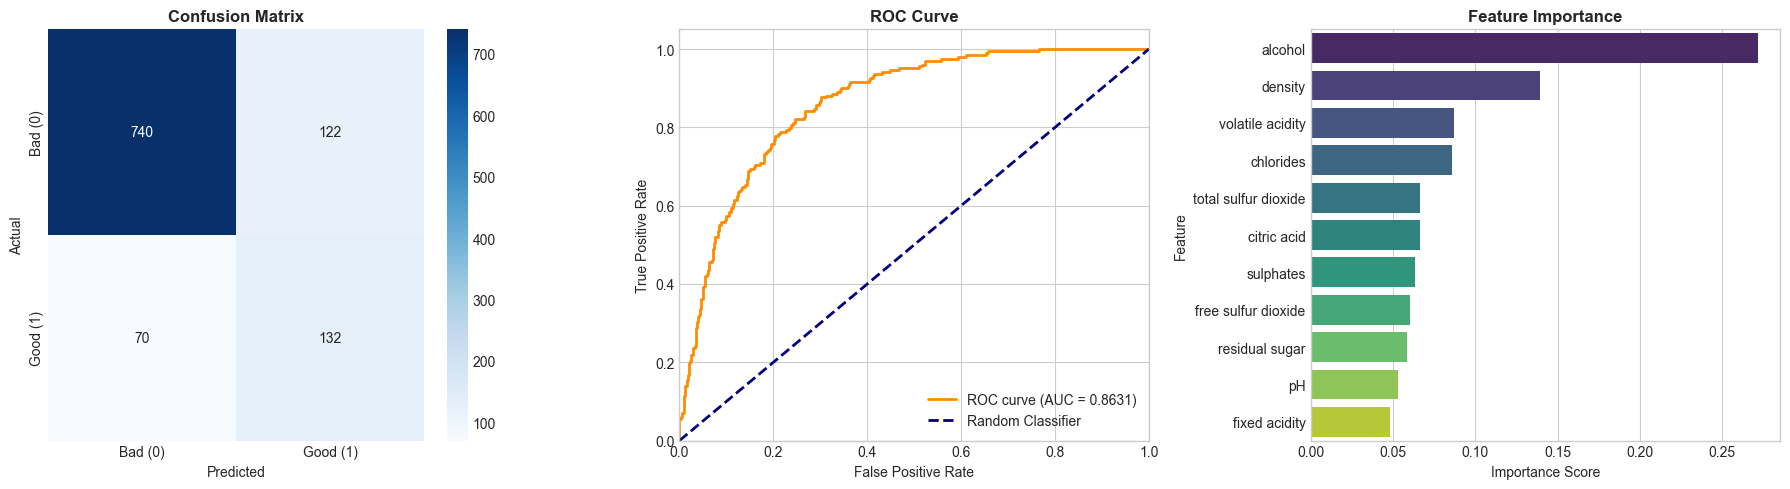

In [38]:
# 6. ОЦЕНКА МОДЕЛИ

print(" ОЦЕНКА МОДЕЛИ")
# Предсказания
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Метрики
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad (0)', 'Good (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n Confusion Matrix:\n{cm}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"\n ROC-AUC: {roc_auc:.4f}")

# Визуализация метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Bad (0)', 'Good (1)'], yticklabels=['Bad (0)', 'Good (1)'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=feature_importance, x='Importance', y='Feature', ax=axes[2], palette='viridis')
axes[2].set_title('Feature Importance', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../notebooks/model_evaluation.png', dpi=300, bbox_inches='tight')
print("\n Графики оценки сохранены в ../notebooks/model_evaluation.png")
plt.show()


In [41]:
# 7. СОХРАНЕНИЕ МОДЕЛИ

print("СОХРАНЕНИЕ МОДЕЛИ")

# Сохранение модели
joblib.dump(model, '../models/wine_model.pkl')
print("\n Модель сохранена: ../models/wine_model.pkl")

# Сохранение scaler
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler сохранён: ../models/scaler.pkl")

# Сохранение метрик
metrics = {
    'accuracy': accuracy,
    'roc_auc': roc_auc,
    'train_size': X_train.shape[0],
    'test_size': X_test.shape[0],
    'feature_names': feature_columns,
    'feature_importance': feature_importance.to_dict()
}
joblib.dump(metrics, '../models/metrics.pkl')
print("Метрики сохранены: ../models/metrics.pkl")

print("ВСЁ ГОТОВО! МОДЕЛЬ ОБУЧЕНА И СОХРАНЕНА!")

СОХРАНЕНИЕ МОДЕЛИ

 Модель сохранена: ../models/wine_model.pkl
Scaler сохранён: ../models/scaler.pkl
Метрики сохранены: ../models/metrics.pkl
ВСЁ ГОТОВО! МОДЕЛЬ ОБУЧЕНА И СОХРАНЕНА!
